# **Statistical Methods for DIS - Problem Sheet 1**
---
## **Lecturer**: Dr Matthew Kenzie | **Supervisor**: Jacob Tutt
### Email: jlt67@cam.ac.uk

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

> ## **Question 1 (a):**
> Get hold of the example dataset stored in the module gitlab page
> - Make some pair plots of the distributions in the dataset and try to become a bit familiar with what the data might be showing.


#### **Seaborn**
- As discussed in lectures seaborn offers some really nice in built plotting functionalities for **statisitcal data visulisation**.
- I would recommned checking out their [documentation](https://seaborn.pydata.org)


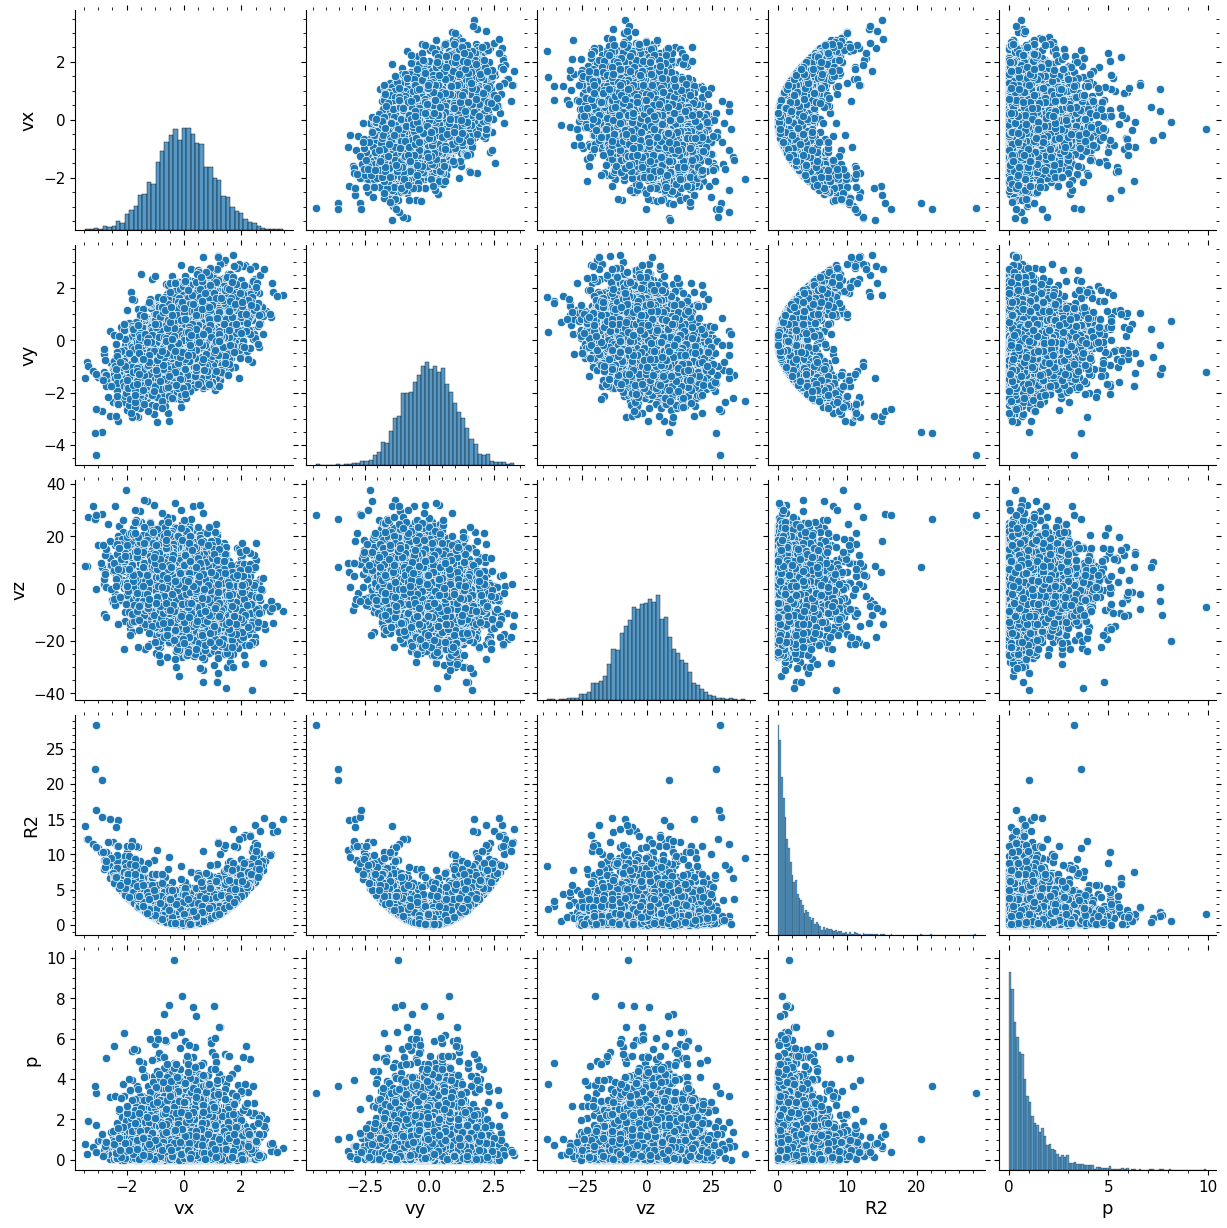

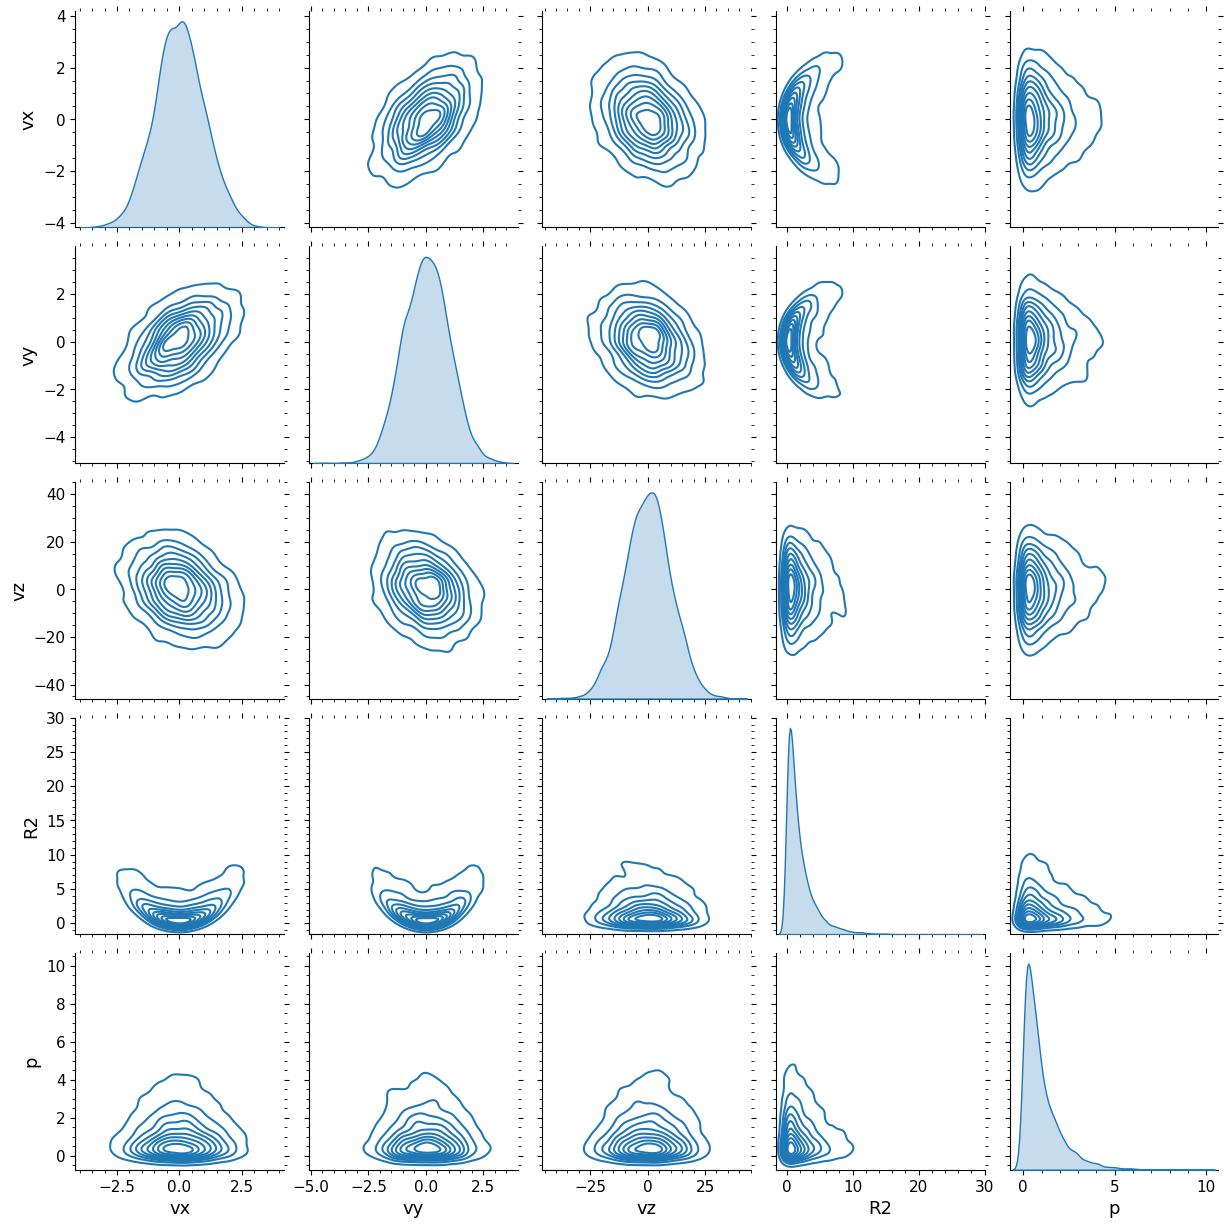

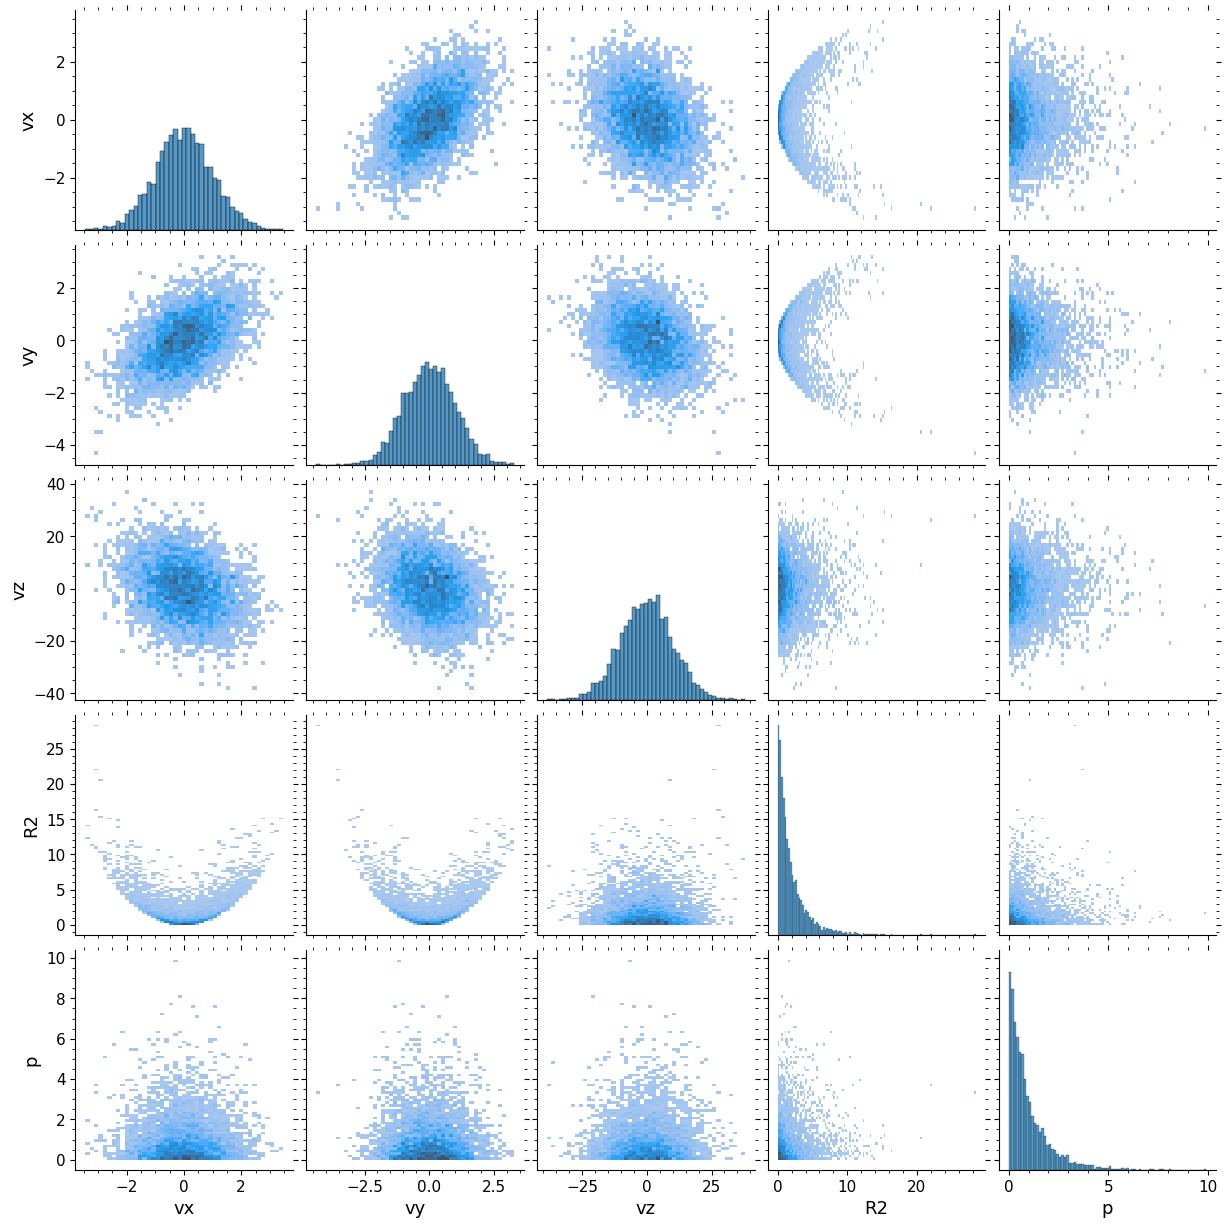

In [6]:
# read the dataset
df = pd.read_pickle("datasets/ps1.pkl")

# Part A
# Make a pair plot using seaborn

# Uncomment and show again once have shown results from part B
plt.style.use('mphil.mplstyle') 

sns.pairplot( df )
sns.pairplot( df, kind='kde')
sns.pairplot( df, kind='hist')

## Discuss the different distributions of each variable - off diagonal axis
## Dicuss the corrolation between the variables and how this comes across in the correlation matrix later
## Discuss the different scales on the axes

> ## **Question 1 (b):**
> - Make a publication quality plot which shows the two-dimensional distribution
between the variables vx and vz.

#### **What Makes it Publication Quality:**
- Data and data trends are clear to see
- Is aesthetically appealing and attractive
- Prints well in black and white and is colour blind safe (not always essential but considered good practise)
- Axis labels and numbers are clearly visible, informative and are not overlapping

Text(0, 0.5, 'Variable B')

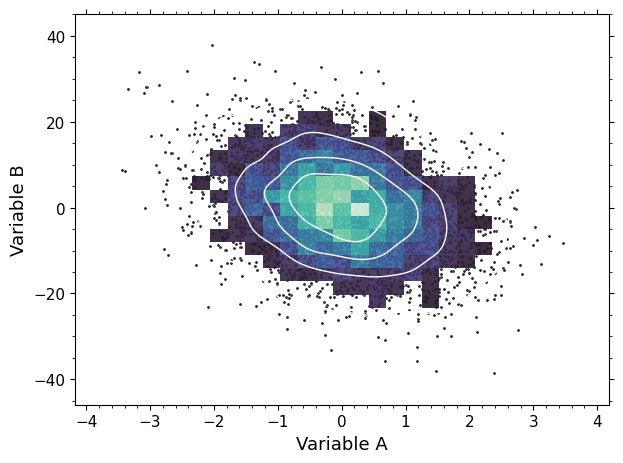

In [6]:
# Part B
# Make a publication style plot
# This is fixed plot setup which is loaded in - show this to the students
plt.style.use('mphil.mplstyle')


fig, ax = plt.subplots()
x, y = df['vx'], df['vz']
sns.scatterplot(x=x, y=y, s=5, color="0.15")
sns.histplot(x=x,y=y, bins=25, pthresh=0.1, cmap="mako", alpha=0.9)
sns.kdeplot(x=x, y=y, levels=5, color='w', linewidths=1)
ax.set_xlabel('Variable A')
ax.set_ylabel('Variable B')


#### **Example Caption**
Figure 1 shows the two-dimensional distribution of data in variables Aand B and
demonstrates the Gaussian nature of the distribution. A small negative correlation
of ρ(A,B) = XX±YY is observed.

#### **The role of the caption:**
- Describe the plot
- Not interpretation - this is for the main body of the text

> ## **Question 1 (c):**
> - Compute the correlation and covariance matrices between all variables in the
dataset.

#### **If done by hand, equations (and code would be):**

#### **Covariance**
- For two variables $X$ and $Y$ with $N$ samples each:
$$
\text{Cov}(X, Y) = \frac{1}{N - 1} \sum_{i=1}^N (X_i - \bar{X})(Y_i - \bar{Y})
$$
- The full **covariance matrix** $\Sigma$ for variables $X_1, X_2, \dots, X_d$ is:
$$
\Sigma_{ij} = \text{Cov}(X_i, X_j)
$$

---

#### **Correlation**
- The **correlation coefficient** between $X$ and $Y$ is:
$$
\rho_{X,Y} = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}
$$
- The full **correlation matrix** $R$ is given by:
$$
R_{ij} = \frac{\Sigma_{ij}}{\sqrt{\Sigma_{ii} \Sigma_{jj}}}
$$

---
- $\bar{X}$ is the mean of $X$.
- $\sigma_X = \sqrt{\text{Var}(X)}$ is the standard deviation of $X$.
- Use numpy or pandas: `df.cov()` and `df.corr()` for fast computation.


In [11]:
# This could be written in code as such
# Convert to numpy array
X = df.to_numpy()
n_samples, n_features = X.shape

# Compute means of each variable (column)
means = np.mean(X, axis=0)
# Center the data (subtract the mean)
X_centered = X - means
# Compute the covariance matrix manually using a matrix multiplication
cov_matrix = (X_centered.T @ X_centered) / (n_samples - 1)
# Compute standard deviations for each variable
std_devs = np.sqrt(np.diag(cov_matrix))
# Scale the the covariance matrix manually to get the correlation matrix
corr_matrix = cov_matrix / np.outer(std_devs, std_devs)

# Display results
cov_df = pd.DataFrame(cov_matrix, columns=df.columns, index=df.columns)
corr_df = pd.DataFrame(corr_matrix, columns=df.columns, index=df.columns)
print("Manual Covariance Matrix:\n", cov_df.round(3))
print("\nManual Correlation Matrix:\n", corr_df.round(3))

Manual Covariance Matrix:
        vx     vy       vz     R2      p
vx  1.003  0.493   -2.852  0.003 -0.001
vy  0.493  0.970   -2.716 -0.003 -0.025
vz -2.852 -2.716  101.234  0.199  0.163
R2  0.003 -0.003    0.199  4.871  0.005
p  -0.001 -0.025    0.163  0.005  1.064

Manual Correlation Matrix:
        vx     vy     vz     R2      p
vx  1.000  0.500 -0.283  0.002 -0.001
vy  0.500  1.000 -0.274 -0.001 -0.024
vz -0.283 -0.274  1.000  0.009  0.016
R2  0.002 -0.001  0.009  1.000  0.002
p  -0.001 -0.024  0.016  0.002  1.000


### **Can also be done using the inbuilt pandas functions:**

In [15]:
# Part C - This can be done using the built in pandas functions
# This built in functionalities of pandas are really useful for quickly getting a feel for the data
print("Manual Covariance Matrix:\n", df.cov().round(3))
print("\nManual Correlation Matrix:\n", df.corr().round(3))


Manual Covariance Matrix:
        vx     vy       vz     R2      p
vx  1.003  0.493   -2.852  0.003 -0.001
vy  0.493  0.970   -2.716 -0.003 -0.025
vz -2.852 -2.716  101.234  0.199  0.163
R2  0.003 -0.003    0.199  4.871  0.005
p  -0.001 -0.025    0.163  0.005  1.064

Manual Correlation Matrix:
        vx     vy     vz     R2      p
vx  1.000  0.500 -0.283  0.002 -0.001
vy  0.500  1.000 -0.274 -0.001 -0.024
vz -0.283 -0.274  1.000  0.009  0.016
R2  0.002 -0.001  0.009  1.000  0.002
p  -0.001 -0.024  0.016  0.002  1.000


#### **A useful functionality for research**
- Often in research you will need to copy the tables across for publication 
- Formatting latex tables can be tedious
- Pandas offers a neat functionality

In [16]:
# This is really useful for when it comes to writing up results in a paper 
# Ie your coursework - automatic latex formating of a pandas dataframe
print( df.corr().to_latex() )
print( df.cov().to_latex() )

\begin{tabular}{lrrrrr}
\toprule
 & vx & vy & vz & R2 & p \\
\midrule
vx & 1.000000 & 0.499943 & -0.283132 & 0.001504 & -0.001291 \\
vy & 0.499943 & 1.000000 & -0.274027 & -0.001331 & -0.024314 \\
vz & -0.283132 & -0.274027 & 1.000000 & 0.008939 & 0.015736 \\
R2 & 0.001504 & -0.001331 & 0.008939 & 1.000000 & 0.002401 \\
p & -0.001291 & -0.024314 & 0.015736 & 0.002401 & 1.000000 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrrr}
\toprule
 & vx & vy & vz & R2 & p \\
\midrule
vx & 1.002608 & 0.493081 & -2.852446 & 0.003324 & -0.001334 \\
vy & 0.493081 & 0.970208 & -2.715740 & -0.002893 & -0.024699 \\
vz & -2.852446 & -2.715740 & 101.233585 & 0.198513 & 0.163291 \\
R2 & 0.003324 & -0.002893 & 0.198513 & 4.871490 & 0.005466 \\
p & -0.001334 & -0.024699 & 0.163291 & 0.005466 & 1.063632 \\
\bottomrule
\end{tabular}



> ## **Question 2:**
> Show that the average deviation from the mean, rather than the squared deviation (i.e. the variance), is not a useful measure of the spread of a distribution. This may lead you to think a decent definition would be the absolute the deviation, can you think why we use the variance (squared deviation) rather than the absolute deviation?

### **Solution:**
Let’s see what happens if we try to use simply the average deviation rather than the average deviation squared:

$$
\frac{1}{N} \sum_i (X_i - \bar{X}) = \frac{1}{N} \sum_i X_i - \frac{1}{N} \sum_i \bar{X} \tag{1}
$$

$$
= \bar{X} - \bar{X} \tag{2}
$$

$$
= 0. \tag{3}
$$

So we always get a spread of zero, hence why we use the squares.

#### What about the mean absolute deviation:

$$
\frac{1}{N} \sum_i |X_i - \bar{X}|. \tag{4}
$$

- This would NOT cause the same issue
- However:
    - The reason this isn’t widely used is because of its rather nasty mathematical behaviour.
    - Differentials of squared quantities give nice linear terms.
    - Differentials of modulus terms is horrible.


> ## **Question 3 (a):**
> The Monty-Hall problem with N doors. In the lectures we saw that in the Monty Hall game show problem with 3 doors it is always advantageous to switch. Sticking on the
initial door has a win outcome with p = 1/3, whereas switching has p = 2/3.
> - Write a numerical simulation of the Monty Hall problem to show that the chance
of winning if you switch is approximately 2/3 but only 1/3 if you stick

### **Equations to keep in your head**
#### **Bayes Theorem:**

$$
P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}
$$

Where:
- $P(A \mid B)$ is the **posterior** probability
- $P(B \mid A)$ is the **likelihood**
- $P(A)$ is the **prior**
- $P(B)$ is the **evidence** (or marginal likelihood)


#### **Theory of Total Probability:**

$$
P(X) = \sum_i P(X \mid Y_i)P(Y_i). \tag{6}
$$






### **Simulating the results**
- We will create a realistic game senario 
- We will then run this repeated number of times (randomly)
- As we increase the number of simulated attempted (by laws of probability) it should converge to theoretical value 

### **Theoretical Values (proof - see part e)**
For a game set up with: 
- **N** doors in total 
- **p** opened by the host
- **k** prizes to be found

**Probabilitiy of Winning**
$$
\frac{k}{N} \frac{N-1}{N-p-1} 
$$
 

In [ ]:
# Discuss the code below
def run_sim( N, k, p ):
    """
    Run Monty Hall simulation

    Parameters
    ----------
    N : int
        The number of boxes
    k : int
        The number of boxes which contain prizes, must have k < N-1
    p : int
        The number of boxes which are revealed by the game show host
        after the initial selection, must have p < N-k
    """

    # make sure number of prizes is less than N-1 0 ie assuming that the host will always reveal at least one box
    if not k < (N-1):
        raise ValueError(f"Cannot have more prizes than number of boxes minus 1, k={k}, N={N}")

    # make sure number of door reveals is less than N-k - otherwise the host would be forced to reveal a prize
    if not p < (N-k):
        raise ValueError(f"Cannot have more box reveals than number of boxes minus number of prizes, p={p}, k={k}, N={N}")

    # box labels - these are the boxes we can choose from
    box_choices = np.arange(1, N+1, dtype=np.int32)

    # randomly choose which prizes boxes are in - randomly select k boxes from the box choices
    prizes = np.random.choice(box_choices, size=k, replace=False)

    # figure out which boxes are not prizes
    not_prizes = np.asarray( [ a for a in box_choices if a not in prizes ] )

    # randomly make an initial choice of box
    initial_choice = np.random.choice(box_choices, size=1)

    # possible reveal boxes - ie the boxes which are not prizes and not the initial choice
    poss_reveals = [ a for a in not_prizes if a not in initial_choice ]

    # randomly reveal other boxes not containing prize - ie a random selection of p boxes from the possible reveals
    reveals = np.random.choice( poss_reveals, size=p,  replace=False )

    # which boxes could now be switched to - ie not the initial choice and not the revealed boxes
    switch_options = [ a for a in box_choices if a not in initial_choice and a not in reveals ]

    # pick a switch box - this would be the box we switch to
    switch_choice = np.random.choice( switch_options, size=1 )

    # let's run some checks we didn't make a mistake
    assert( len(box_choices) == len(prizes)+len(not_prizes) )
    assert( sorted(box_choices) == sorted( np.concatenate( [prizes, not_prizes] ) ) )

    # Win outcomes in both cases - either true or false in each case
    # Ie was the initial choice a prize
    win_stick = initial_choice in prizes
    # Ie was the switch choice a prize
    win_switch = switch_choice in prizes

    return win_stick, win_switch

# This is the mathematical theory behind the Monty Hall problem - proved in question part e
def theory( N, k, p ):
    prob_win_switch = (k/N)*( (N-1)/(N-p-1) )
    prob_win_stick  = 1 - prob_win_switch
    return prob_win_stick, prob_win_switch


# Run the simulation for Ntrials to get a good estimate of the winning probabilities
# It should converge to the theoretical values
def run_ntrials( Ntrials, N, k, p, seed=None ):
    if seed:
        np.random.seed(seed)

    Nwin_stick  = 0
    Nwin_switch = 0

    stick_win_tracker = []
    switch_win_tracker = []

    for i in tqdm(range(Ntrials)):
        win_stick, win_switch = run_sim( N, k, p)
        if win_switch:
            Nwin_switch += 1
        else:
            Nwin_stick += 1

        stick_win_tracker.append( Nwin_stick )
        switch_win_tracker.append( Nwin_switch )

    stick_win_tracker = np.asarray( stick_win_tracker )
    switch_win_tracker = np.asarray( switch_win_tracker )

    fig, ax = plt.subplots()
    x = np.arange(1, Ntrials+1, 1)

    stick_win_frac = stick_win_tracker / x 
    switch_win_frac = switch_win_tracker / x

    res_stick = stick_win_frac[-1]
    res_switch = switch_win_frac[-1]

    # compute the theory line
    th_win_stick, th_win_switch = theory( N, k, p )
    
    ax.plot(x, stick_win_frac, lw=2, label='Stick (simulation)')
    ax.plot(x, switch_win_frac, lw=2, label='Switch (simulation)')
    ax.axhline( th_win_stick, c='C0', ls='--', label='Stick (theory)')
    ax.axhline( th_win_switch, c='C1', ls='--', label='Switch (theory)')
    ax.text(0.1,0.9, f'Parameters: N={N}, k={k}, p={p}', transform=ax.transAxes)
    ax.text(0.1,0.8, r'Theory: $p(\mathrm{win}) = \frac{k}{N}\frac{N-1}{N-p-1} = $'+f"{(100*((k/N)*((N-1)/(N-p-1)))):.3g}%", transform=ax.transAxes)
    ax.text(Ntrials, res_stick+0.01, f'${100*res_stick:3.1f}\%$', color='C0', va='bottom', ha='right')
    ax.text(Ntrials, res_switch+0.01, f'${100*res_switch:3.1f}\%$', color='C1', va='bottom', ha='right')

    ax.set_xlabel('Number of simulations')
    ax.set_ylabel('Chance of winning')
    ax.legend()

### **The Mathematical Approach:**
**For N = 3, k= 1, p= 1:**

There are 3 boxes A, B, C. Let’s assume that:
- we pick box A 
- the host opens box B. 
- The prize is randomly assigned

Note, that this covers all possibilities because we can simply re-name the boxes for a different ordering.

---
#### **Probability win by sticking - ie car is in box A**

$$
P(\text{Win by sticking}) = P(\text{car in A} \mid \text{host opens B})
$$


From **Bayes’ theorem**:

$$
P(\text{car in A} \mid \text{host opens B}) = \frac{P(\text{host opens B} \mid \text{car in A}) \cdot P(\text{car in A})}{P(\text{host opens B})}
$$

--- 
The terms on the right-hand numerator:
$$
P(\text{host opens B} \mid \text{car in A}) = \frac{1}{2}
$$
$$
P(\text{car in A}) = \frac{1}{3}
$$

--- 

The right-hand side denominator:
- How do we compute the probability the host opens B **because it depends on different outcomes** i.e. whether the prize is already in A or not.  
- Exploit the theory of total probability* (the sum over all possibilities).

$$
P(X) = \sum_i P(X \mid Y_i)P(Y_i). 
$$

So that in our case:

$$
P(\text{host opens B}) = P(\text{host opens B} \mid \text{car in A}) P(\text{car in A})  
+ P(\text{host opens B} \mid \text{car in C}) P(\text{car in C}) 
$$

$$
= \frac{1}{2} \cdot \frac{1}{3} + 1 \cdot \frac{1}{3} 
$$

$$
= \frac{1}{6} + \frac{1}{3} 
$$

$$
= \frac{1}{2}. 
$$

> *Incidentally, many find this probability easy to intuit: either the host will open B or C with equal probability.*

---

Now we can plug the numbers back into Bayes’ theorem so that:

$$
P(\text{car in A} \mid \text{host opens B}) = \frac{P(\text{host opens B} \mid \text{car in A}) \cdot P(\text{car in A})}{P(\text{host opens B})} 
$$

$$
= \frac{\frac{1}{2} \cdot \frac{1}{3}}{\frac{1}{2}} = \frac{1}{3}
$$

$$
\textbf{Winning by Sticking = (33.33\%)}
$$

---

#### **Probability win by switching - ie car is in box C**

$$
P(\text{Win by Switching}) = P(\text{car in C} \mid \text{host opens B})
$$


$$
P(\text{car in C} \mid \text{host opens B}) = \frac{P(\text{host opens B} \mid \text{car in C}) \cdot P(\text{car in C})}{P(\text{host opens B})} 
$$

$$
= \frac{1 \cdot \frac{1}{3}}{\frac{1}{2}} = \frac{2}{3} 
$$

$$
\textbf{Winning by Switching = (66.67\%)}
$$


### **Verification Through Simulation**
**For N = 3, k= 1, p= 1:**

100%|██████████| 5000/5000 [00:00<00:00, 18486.07it/s]


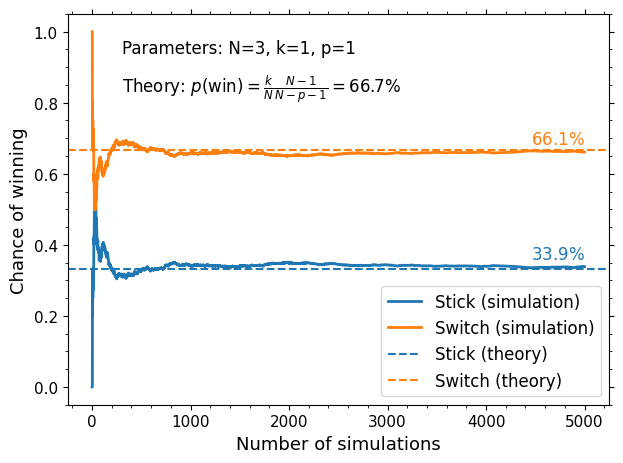

In [38]:
# Number of simulation trials to run
ntrials = 5000
# Number of boxes in the game show
nboxes = 3
# Number of boxes which contain prizes
nprizes = 1
# Number of boxes which are revealed by the game show host
nreveal = 1
# Random seed for reproducibility
seed = 5

run_ntrials( ntrials, nboxes, nprizes, nreveal, seed=seed)

> ## **Question 3 (b):**
> - Now imagine there are 100 doors (still with only one car) and that after your
initial choice the game show host opens 98 of them to reveal goats. Compute the
probabilities of winning if you stick or switch. Perhaps this will help convince
you (if Bayes’ theorem didn’t already) that switching is a good strategy.

### **The Mathematical Approach:**
**For N = 100, k= 1, p= 98:**

There are 100 boxes i = 1, ... 100 . Let’s assume that:
- we pick box i = 1
- the host opens box i = 2, ..., 99
- The prize is randomly assigned

Note, that this covers all possibilities because we can simply re-name the boxes for a different ordering.

---
#### **Probability win by sticking - ie car is in box i = 100**

$$
P(\text{Win by Sticking}) = P(\text{car in 1} \mid \text{host opens 2–99})
$$

From **Bayes’ theorem**:

$$
P(\text{car in 1} \mid \text{host opens 2–99}) = \frac{P(\text{host opens 2–99} \mid \text{car in 1}) \cdot P(\text{car in 1})}{P(\text{host opens 2–99})}
$$

--- 
The terms on the right-hand numerator:


$$
P(\text{host opens 2–99} \mid \text{car in 1}) = \frac{1}{\text{Number of Options/ Permutations}} = \frac{1}{\binom{99}{98}}= \frac{1}{99}
$$

$$
P(\text{car in 1}) = \frac{1}{100}
$$

--- 

The right-hand side denominator:
- **Exploit the theory of total probability**:

$$
P(X) = \sum_i P(X \mid Y_i)P(Y_i). 
$$

So that in our case:


$$
P(\text{host opens 2–99}) = \sum_i P(B \mid A_i)P(A_i)
$$

$$
= P(\text{host opens 2–99} \mid \text{car in 1}) P(\text{car in 1})  
+ P(\text{host opens 2–99} \mid \text{car in 100}) P(\text{car in 100})
$$

$$
= \frac{1}{99} \cdot \frac{1}{100} + 1 \cdot \frac{1}{100}
$$

$$
= \frac{1}{100} \left( \frac{1}{99} + 1 \right)
= \frac{1}{99}
$$

---

Now we can plug into Bayes’ Theorem:

$$
P(\text{car in 1} \mid \text{host opens 2–99}) = \frac{\frac{1}{99} \cdot \frac{1}{100}}{\frac{1}{99}} = \frac{1}{100}
$$

$$
\textbf{Winning by Sticking = (1.00\%)}
$$

---

#### **Probability win by switching — i.e. car is in box 100**

$$
P(\text{Win by Switching}) = P(\text{car in 100} \mid \text{host opens 2–99})
$$

$$
= \frac{P(\text{host opens 2–99} \mid \text{car in 100}) \cdot P(\text{car in 100})}{P(\text{host opens 2–99})}
$$

$$
= \frac{1 \cdot \frac{1}{100}}{\frac{1}{99}} = \frac{99}{100}
$$

$$
\textbf{Winning by Switching = (99.00\%)}
$$

---

### **Verification Through Simulation**
**For N = 100, k = 1, p = 98:**

100%|██████████| 5000/5000 [00:02<00:00, 1770.01it/s]


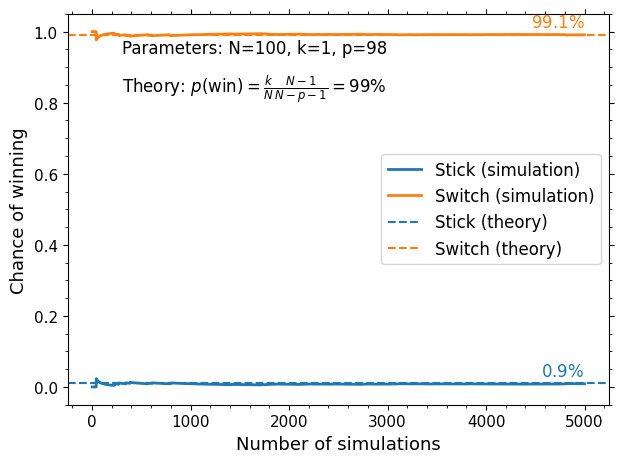

In [39]:
# Number of simulation trials to run
ntrials = 5000
# Number of boxes in the game show
nboxes = 100
# Number of boxes which contain prizes
nprizes = 1
# Number of boxes which are revealed by the game show host
nreveal = 98
# Random seed for reproducibility
seed = 5

run_ntrials( ntrials, nboxes, nprizes, nreveal, seed=seed)

> ## **Question 3 (c):**
> - It should now be trivial for you to write down an expression (but it’s also instructive to prove it) for the case where there are N doors and the host opens N − 2.

### **Simply a generalisation of the above:**
- Follow through the same maths as above:

**For N = N, k= 1, p= N-1:**

There are N boxes i = 1, ... N . Let’s assume that:
- we pick box i = 1
- the host opens box i = 2, ..., N-1
- The prize is randomly assigned

---
#### **Probability win by sticking - ie car is in box i = 1**

$$
P(\text{Win by Sticking}) = P(\text{car in 1} \mid \text{host opens 2–(N-1)})
$$

From **Bayes’ theorem**:

$$
P(\text{car in 1} \mid \text{host opens 2–(N-1)}) = \frac{P(\text{host opens 2–(N-1)} \mid \text{car in 1}) \cdot P(\text{car in 1})}{P(\text{host opens 2–(N-1)})}
$$

--- 
The terms on the right-hand numerator:


$$
P(\text{host opens 2–(N-1)} \mid \text{car in 1}) = \frac{1}{\text{Number of Options/ Permutations}} = \frac{1}{\binom{N-1}{N-2}}= \frac{1}{N-1}
$$

$$
P(\text{car in 1}) = \frac{1}{N}
$$

--- 

The right-hand side denominator:
- **Exploit the theory of total probability**:

$$
P(X) = \sum_i P(X \mid Y_i)P(Y_i). 
$$

So that in our case:


$$
P(\text{host opens 2–(N-1)}) = \sum_i P(B \mid A_i)P(A_i)
$$

$$
= P(\text{host opens 2–(N-1)} \mid \text{car in 1}) P(\text{car in 1})  
+ P(\text{host opens 2–(N-1)} \mid \text{car in N}) P(\text{car in N})
$$

$$
= \frac{1}{N-1} \cdot \frac{1}{N} + 1 \cdot \frac{1}{N}
$$

$$
= \frac{1}{N} \left( \frac{1}{N-1} + 1 \right)
= \frac{1}{N-1}
$$

---

Now we can plug into Bayes’ Theorem:

$$
P(\text{car in 1} \mid \text{host opens 2–(N-1)}) = \frac{\frac{1}{N-1} \cdot \frac{1}{N}}{\frac{1}{N-1}} = \frac{1}{N}
$$

$$
\textbf{Winning by Sticking} = \frac{1}{N}
$$

---

#### **Probability win by switching — i.e. car is in box N**

$$
P(\text{Win by Switching}) = P(\text{car in N} \mid \text{host opens 2–(N-1)})
$$

$$
= \frac{P(\text{host opens 2–(N-1)} \mid \text{car in N}) \cdot P(\text{car in N})}{P(\text{host opens 2–(N-1)})}
$$

$$
= \frac{1 \cdot \frac{1}{N}}{\frac{1}{N-1}} = \frac{N-1}{N}
$$

$$
\textbf{Winning by Switching} = \frac{N-1}{N}
$$


> ## **Question 3 (d):**
> - Show that if there are N doors and the host opens p of them that the probability
of winning if you switch is
> $$
\frac{1}{N} \frac{N-1}{N-p-1} 
>$$
> - You can always go back to your simulation to check this.

### **Mathematical Formulation:**
#### **Using Intuitive Probabilities**

#### **The trick with these questions is to think about clever ways of dividing them up into *latent cases***

Let’s suppose we have:

- $ N  $ boxes  
- 1 prize  
- $ p $ empty doors revealed by the host  

Once you initially pick a box and the host reveals $ p $ empty boxes:
- there are $ N - p - 1 $ boxes remaining to choose from

---

#### **There are two *latent* cases:**
#### **Case 1: You Initially Picked the Wrong Box**

- Probability you picked the wrong box:
$$
P(\text{picked wrong}) = \frac{N - 1}{N}
$$

- Since the prize is among the remaining  N - 1 - p boxes:
	- Only 1 of these contains the prize.
	- So, the probability of switching to the prize in this case is:
$$
P(\text{switch to prize} \mid \text{picked wrong}) = \frac{1}{N - 1 - p}
$$

#### **Case 2: You Initially Picked the Correct Box**
- Probability you picked the correct box:
$$
P(\text{picked right}) = \frac{1}{N}
$$

- If you picked correctly and then switch, you will always lose.
$$
P(\text{switch to prize} \mid \text{picked right}) = 0
$$


#### **The probability of winning if you switch is:**

$$
P(\text{switch to prize}) = P(\text{switch to prize} \mid \text{picked wrong}) \times P(\text{picked wrong}) + P(\text{switch to prize} \mid \text{picked right}) \times P(\text{picked right})
$$


$$
= \frac{1}{N - p - 1} \cdot \frac{N - 1}{N} + 0 \cdot \frac{1}{N} 
$$

$$
= \frac{N - 1}{N} \cdot \frac{1}{N - p - 1}
$$

---

#### **Finally Expression**

$$
P(\text{Win on Switch}) = \frac{1}{N} \cdot \frac{N - 1}{N - p - 1}
$$

### An example with the simulation
**For N = 100, k= 1, p= 10:**

#### **By Maths:**
$$
P(\text{Win on Switch}) = \frac{1}{100} \cdot \frac{100 - 1}{100 - 10 - 1} = \frac{99}{8900}  \approx 0.0111 \text{ or } 1.11\%
$$

#### **By Simulation:**


100%|██████████| 5000/5000 [00:02<00:00, 1730.63it/s]


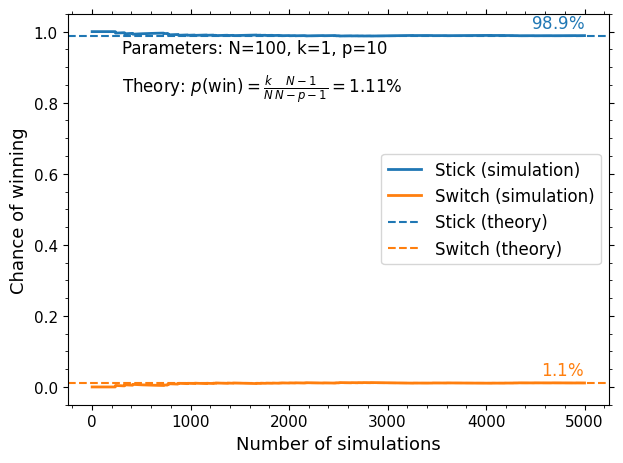

In [40]:
# Number of simulation trials to run
ntrials = 5000
# Number of boxes in the game show
nboxes = 100
# Number of boxes which contain prizes
nprizes = 1
# Number of boxes which are revealed by the game show host
nreveal = 10
# Random seed for reproducibility
seed = 5

run_ntrials( ntrials, nboxes, nprizes, nreveal, seed=seed)

> ## **Question 3 (e):** (Extension)
> - Show that if there are N boxes, containing k prizes and the host opens p of them, then the probability of winning if you switch is:
> $$
\frac{k}{N} \frac{N-1}{N-p-1} 
>$$
> - You can always go back to your simulation to check this.

### **Mathematical Formulation:**
#### **Using Intuitive Probabilities**

Let’s suppose we have:

- $ N  $ boxes  
- k prize  
- $ p $ empty doors revealed by the host  

Once you initially pick a box and the host reveals $ p $ empty boxes:
- there are $ N - p - 1 $ boxes remaining to choose from

---

#### **There are two *latent* cases:**
#### **Case 1: You Initially Picked the Wrong Box**

- Probability you picked the wrong box:
  $$
  P(\text{picked wrong}) = \frac{N - k}{N}
  $$

- Since the prize is among the remaining $ N - 1 $ boxes and $ p $ are revealed, the switchable boxes are $ N - p - 1 $ in total.

- Among those, $ k $ boxes contain prizes (but 1 of them was possibly picked), so in this case, **all $ k $ prizes are still available for switching**.

- So, the probability of switching to a prize:
  $$
  P(\text{switch to prize} \mid \text{picked wrong}) = \frac{k}{N - p - 1}
  $$


#### **Case 2: You Initially Picked the Correct Box**

- Probability you picked a prize box:
  $$
  P(\text{picked right}) = \frac{k}{N}
  $$

- If you picked correctly and switch, then you are switching away from a prize.  
  But only $ k - 1 $ prizes remain among the $ N - p - 1 $ boxes you can now choose from.

- So, the probability of switching to a prize:
  $$
  P(\text{switch to prize} \mid \text{picked right}) = \frac{k - 1}{N - p - 1}
  $$

---

#### **Apply the Law of Total Probability**

So the total probability of **winning if you switch** is:

$$
P(\text{Win on Switch}) =
P(\text{picked wrong}) \cdot P(\text{switch to prize} \mid \text{picked wrong})
+ P(\text{picked right}) \cdot P(\text{switch to prize} \mid \text{picked right})
$$

Substituting:

$$
= \frac{N - k}{N} \cdot \frac{k}{N - p - 1}
+ \frac{k}{N} \cdot \frac{k - 1}{N - p - 1}
$$

Factor and simplify:

$$
= \frac{k(N - k) + k(k - 1)}{N(N - p - 1)} 
= \frac{k(N - 1)}{N(N - p - 1)}
$$
---

#### **Finally Expression**

$$
P(\text{Win on Switch}) = \frac{k}{N} \frac{(N - 1)}{(N - p - 1)}
$$

### An example with the simulation
**For N = 100, k= 10, p= 10:**

#### **By Maths:**
$$
P(\text{Win on Switch}) =
\frac{10}{100} \cdot \frac{99}{100 - 10 - 1} =
\frac{1}{10} \cdot \frac{99}{89} = \frac{99}{890} \approx 0.1111 \text{ or } 11.11\%
$$

#### **By Simulation:**

100%|██████████| 5000/5000 [00:02<00:00, 1756.64it/s]


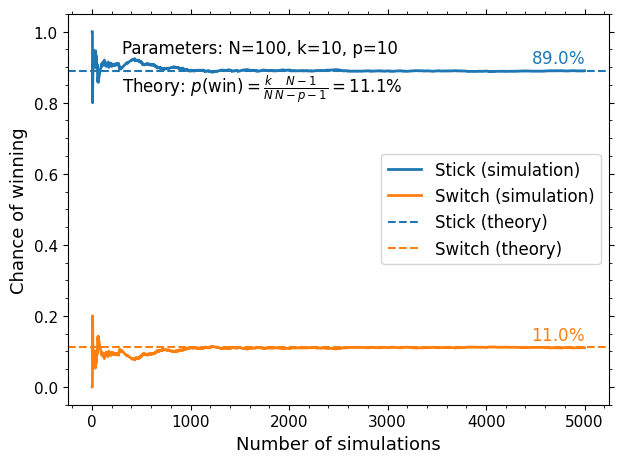

In [41]:
# Number of simulation trials to run
ntrials = 5000
# Number of boxes in the game show
nboxes = 100
# Number of boxes which contain prizes
nprizes = 10
# Number of boxes which are revealed by the game show host
nreveal = 10
# Random seed for reproducibility
seed = 5

run_ntrials( ntrials, nboxes, nprizes, nreveal, seed=seed)

> ## **Question 3 (f):** (Extension)
> - Show that if there are N doors, containing k prizes, where the contestant intially selects m doors and the host opens p boxes which reveal r prizes, then you should switch doors providing the proportion of prizes revealed by the host is smaller than the proportion in the intial configuration, i.e. if the following condition is met:
> $$
\frac{r}{p} < \frac{k}{N}
> $$
> - It is easier to first consider the case where there is only a single initial doorchosen, m = 1. 
> - You can then consider the case where m > 1 and a “switch” in this context means switching all of the initial choice for a new set of m doors (this does require that there are sufficient doors remaining so that this switch can be done, i.e. that m ≤ N − p − m, but you don’t need this constraint to solve the problem). 
> - You may finally consider the case where one is allowed to switch some
subset of m, call this ℓ, doors. In all of these cases the same equality condition
applies that you should switch if r/p < k/N . 
> - For this last part (or indeed for all of the parts) you may find it easier to start thinking about the expected number
of prizes and making the choice which maximises the expected number of prizes

## **Solution**
### **Starting with the case where m=1:**


#### **There are two *latent* cases:**
#### **Case 1: You Initially Picked the Wrong Box**

- Probability you picked the wrong box:
  $$
  P(\text{picked wrong}) = \frac{N - k}{N}
  $$

- Since the k prizes is among the remaining $ N - 1 $ boxes and $ r $ are revealed when showing $p$ boxes , the switchable boxes are $ N - p - 1 $ in total.

- Among those, $ k-r $ boxes contain prizes

- So, the probability of switching to a prize:
  $$
  P(\text{switch to prize} \mid \text{picked wrong}) = \frac{k - r}{N - p - 1}
  $$


#### **Case 2: You Initially Picked the Correct Box**

- Probability you picked a prize box:
  $$
  P(\text{picked right}) = \frac{k}{N}
  $$

- If you picked correctly and switch, then you are switching away from a prize.  
  But only $ k - r - 1 $ prizes remain among the $ N - p - 1 $ boxes you can now choose from.

- So, the probability of switching to a prize:
  $$
  P(\text{switch to prize} \mid \text{picked right}) = \frac{k - r - 1}{N - p - 1}
  $$


Total probability of winning when switching:

$$
P(\text{Win on Switch}) = P(\text{switched to prize} \mid \text{picked wrong}) \cdot P(\text{picked wrong}) + P(\text{switched to prize} \mid \text{picked right}) \cdot P(\text{picked right})
$$

Plugging in the general expressions:

$$
= \frac{k - r}{N - p - 1} \cdot \frac{N - k}{N} +  \frac{k - r - 1}{N - p - 1} \cdot \frac{k}{N}
$$

Combine the terms:

$$
= \frac{k(N - 1) - rN}{N(N - p - 1)}
$$

⸻

When is Switching Better?

Switching is the best strategy if it gives a larger probability than the initial chance of being correct, which is:

$$
\frac{k}{N}
$$

So we compare:

$$
\frac{k(N - 1) - rN}{N(N - p - 1)} > \frac{k}{N} 
$$

Multiply both sides by N(N - p - 1):

$$
k(N - 1) - rN > k(N - p - 1) 
$$

Rearranging:

$$
-rN > -kp 
$$

Which gives:

$$
rN < kp 
$$

Finally:

$$
\boxed{
\frac{r}{p} < \frac{k}{N}
} 
$$


### **Moving to the case where m > 1:**
- Consider this as trying to maximise your expected number of prizes.

#### **Expected Prizes from Initial Picks**

If you pick m boxes and each of them has a chance of having a prize of $ \frac{k}{N} $, then:

$$
\langle N \text{ prizes} \rangle = m \cdot \frac{k}{N}
$$

#### **Expected Prizes from Boxes You Didn’t Choose**

You didn’t choose N - m boxes, so:

$$
\langle N \text{ prizes} \rangle = (N - m) \cdot \frac{k}{N}
$$

However, if the host reveals p boxes and r of them contain prizes, then those r prizes are no longer winnable. So the expected number of remaining prizes becomes:

$$
\langle N \text{ prizes} \rangle = (N - m) \cdot \frac{k}{N} - r 
$$

#### **Expected Prizes per Remaining Box**

The remaining number of boxes is N - p - m, so:

$$
\langle N \text{ prizes per box} \rangle = \frac{(N - m)k/N - r}{N - p - m}
= \frac{(N - m)k - rN}{N(N - p - m)} \tag{54}
$$


#### **Expected Prizes After Switching**

If you switch all m boxes for new ones, the expected number of prizes becomes:

$$
\langle N \text{ prizes} \rangle = m \cdot \frac{(N - m)k - rN}{N(N - p - m)} 
$$


#### **When is Switching Better?**

We now compare this to sticking with the original boxes, which had expected value:

$$
m \cdot \frac{k}{N}
$$

So we solve:

$$
m \cdot \frac{(N - m)k - rN}{N(N - p - m)} > m \cdot \frac{k}{N} 
$$

Cancelling m and multiplying both sides:

$$
\frac{(N - m)k - rN}{N - p - m} > k 
$$

Multiply both sides:

$$
Nk - mk - rN > kN - pk - mk 
$$

Simplify:

$$
-rN > -pk
$$

Which implies:

$$
\boxed{\frac{r}{p} < \frac{k}{N}} 
$$


> ## **Question 4:**
> Show that for a binomial distribution with n trials and a success rate of p that the sum of all possible outcomes is unity. In other words, prove that the binomial p.d.f. is properly normalised.

### **Defining the Binomial Distribution:**
$$
P(k; p, n) = \frac{n!}{k!(n - k)!} p^k (1 - p)^{n - k}
$$
- This is a discrete distribution so sum over
- if it was continuous what would we do?

### **Approach 1 - Newton’s Binomial Theorem:**
The binomial expansion states:
$$
(1 + x)^n = 1 + nx + \frac{n(n - 1)}{2!} x^2 + \frac{n(n - 1)(n - 2)}{3!} x^3 + \cdots + x^n
$$

Or more compactly:

$$
(1 + x)^n = \sum_{k = 0}^{n} \frac{n!}{k!(n - k)!} x^k
$$

Sum over all binomial cases - ie number of expansions k:

$$
\sum_{k = 0}^{n} P(k; p, n) = \sum_{k = 0}^{n} \frac{n!}{k!(n - k)!} p^k (1 - p)^{n - k}
$$

Factor out $(1 - p)^n$:

$$
= \sum_{k = 0}^{n} \frac{n!}{k!(n - k)!} \cdot \frac{p^k (1 - p)^n}{(1 - p)^k}
= (1 - p)^n \sum_{k = 0}^{n} \frac{n!}{k!(n - k)!} \left( \frac{p}{1 - p} \right)^k
$$

Recognising this as a binomial expansion:

$$
= (1 - p)^n \left( 1 + \frac{p}{1 - p} \right)^n
$$

Simplify the bracket:

$$
= (1 - p)^n \left( \frac{1 - p + p}{1 - p} \right)^n
= (1 - p)^n \left( \frac{1}{1 - p} \right)^n
$$

Thus:

$$
= 1
$$

### **Approach 1 - General Binomial Formula:**

Using the identity:

$$
(a + b)^n = \sum_{i = 0}^{n} \frac{n!}{i!(n - i)!} a^i b^{n - i}
$$

We can simply choose:
- a = p 
- b = 1 - p

$$
\sum_{k = 0}^{n} \frac{n!}{k!(n - k)!} p^k (1 - p)^{n - k} = (a + b)^n = ( p + 1 - p)^n = 1
$$



> ## **Question 5 (a):**
> Imagine trying to “track” the path of some projectile using a set of cameras at fixed positions. You need at least three measurements of the projectile to accurately predict its motion (because it is accelerating). The “hit” efficiency for a single camera is 95% (in other words it will completely miss the projectile 5% of the time).
> - If we require a minimum of three hits, how efficient would the system be with three cameras?

## **Solution:**
Notice this is a binomial distribution:
- **n** - Number of Trials: 3 
- **p** - P(hit/success) = 0.95
    - P(miss/failure) =  0.05
- **k** - Number of successes required: 3

**Probability of three hits:**
$$
P(3; 0.95, 3) = \frac{3!}{3!(3 - 3)!} (0.95)^k (1 - 0.95)^{3 - 3} = 0.95^3 = 0.857 = \boxed{85.7\%}
$$

> ## **Question 5 (b):**
> - Would having four or five give a significant improvement (once again requiring at least 3 hits)?

### **Case 1: Four cameras**

$$
P(3; 0.95, 4) = \binom{4}{3} (0.95)^3 (0.05)^1 = 4 \cdot 0.857 \cdot 0.05 = 0.171
$$

$$
P(4; 0.95, 4) = \binom{4}{4} (0.95)^4 (0.05)^0 = 1 \cdot 0.95^4 = 0.815
$$

$$
P(\text{3 or more hits};\ 4\ \text{cameras}) = 0.171 + 0.815 = \boxed{98.6\%}
$$

---

### **Case 2: Five cameras**

$$
P(3; 0.95, 5) = \binom{5}{3} (0.95)^3 (0.05)^2 = 10 \cdot 0.857 \cdot 0.0025 = 0.021
$$

$$
P(4; 0.95, 5) = \binom{5}{4} (0.95)^4 (0.05)^1 = 5 \cdot 0.815 \cdot 0.05 = 0.204
$$

$$
P(5; 0.95, 5) = \binom{5}{5} (0.95)^5 (0.05)^0 = 1 \cdot 0.95^5 = 0.774
$$

$$
P(\text{3 or more hits};\ 5\ \text{cameras}) = 0.021 + 0.204 + 0.774 = \boxed{99.9\%}
$$

---

### **Conclusion:**
- With 3 cameras: 85.7% efficiency
- With 4 cameras: 98.6% efficiency
- With 5 cameras: 99.9% efficiency

> ## **Question 6:**
> Show that the sum of two independent Poisson distributed variables is also Poisson distributed. In other words show that if X is distributed according to Poiss(X; λX ) and Y is distributed according to Poiss(Y ; λY ) then Z = X +Y is distributed according to Poiss(Z; λZ ), and find the value of λZ 

## **Solution**

The Poisson p.m.f. is given by:

$$
P(k; \lambda) = \frac{e^{-\lambda} \lambda^k}{k!}. 
$$

---

We exploit the **Binomial expansion** again:

$$
(a + b)^n = \sum_{i = 0}^n \frac{n!}{i!(n - i)!} a^i b^{n - i}. 
$$

---

For the sum of two Poisson variables:

Let $ Z = X + Y $, where:
- $ X \sim \text{Poisson}(\lambda_X) $
- $ Y \sim \text{Poisson}(\lambda_Y) $

Then the total probability is:

$$
P(Z) = \sum_{x = 0}^{Z} P(X = x; \lambda_X) \cdot P(Z - x; \lambda_Y) 
$$

Expanding each term:

$$
= \sum_{x = 0}^{Z} \frac{e^{-\lambda_X} \lambda_X^x}{x!} \cdot \frac{e^{-\lambda_Y} \lambda_Y^{Z - x}}{(Z - x)!} 
$$

Factor constants outside the sum:

$$
= e^{-\lambda_X} e^{-\lambda_Y} \sum_{x = 0}^{Z} \frac{\lambda_X^x \lambda_Y^{Z - x}}{x!(Z - x)!}
$$

Rewriting with $ Z! $ and binomial coefficient:

$$
= \frac{e^{-\lambda_X} e^{-\lambda_Y}}{Z!} \sum_{x = 0}^{Z} \binom{Z}{x} \lambda_X^x \lambda_Y^{Z - x} 
$$

Use binomial expansion $ (\lambda_X + \lambda_Y)^Z $:

$$
= \frac{e^{-(\lambda_X + \lambda_Y)} (\lambda_X + \lambda_Y)^Z}{Z!} 
$$

---

This is a Poisson distribution with mean:

$$
\lambda_Z = \lambda_X + \lambda_Y
$$



### Characteristic function 